In [ ]:
import torch
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

# 1. Get a sample image built into the 'skimage' library (a famous picture of an astronaut)
image = data.astronaut()

# 2. Convert it to grayscale.
# Color images have 3 layers (Red, Green, Blue). Grayscale is just 1 layer,
# which makes the math much easier to learn on!
gray_image = rgb2gray(image)

# 3. Convert the normal image array into a PyTorch Tensor
img_tensor = torch.tensor(gray_image, dtype=torch.float32)

print(f"Original image dimensions: {img_tensor.shape}")

Original image dimensions: torch.Size([512, 512])


In [ ]:
# Perform Singular Value Decomposition
# This splits our image into three parts: U, S (Singular values), and Vh (V transposed)
U, S, Vh = torch.linalg.svd(img_tensor, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"S (Singular values) shape: {S.shape}")
print(f"Vh shape: {Vh.shape}")


U shape: torch.Size([512, 512])
S (Singular values) shape: torch.Size([512])
Vh shape: torch.Size([512, 512])


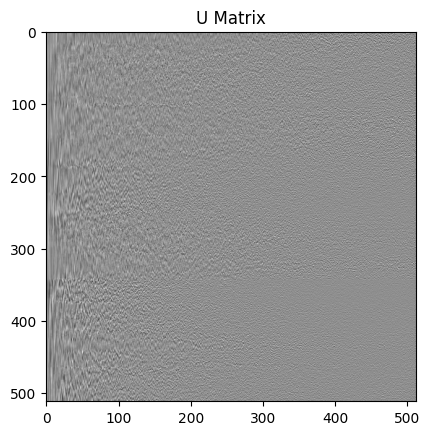

In [ ]:
plt.imshow(U, cmap='gray')
plt.title("U Matrix")
plt.show()

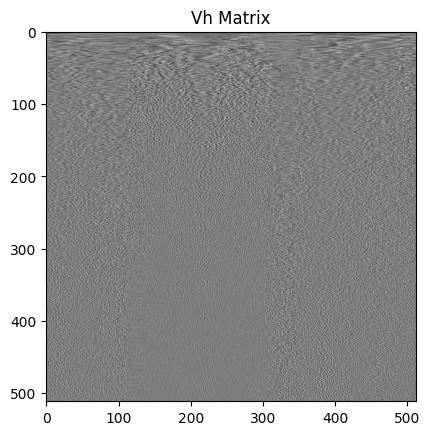

In [ ]:
plt.imshow(Vh, cmap='gray')
plt.title("Vh Matrix")
plt.show()

In [ ]:
def compress_image(k, U, S, Vh):
    # Keep only the top 'k' columns/rows of our three pieces
    U_k = U[:, :k]

    # S is just a list of numbers. We need to turn it back into a diagonal grid
    S_k = torch.diag(S[:k])

    Vh_k = Vh[:k, :]

    # Multiply the three pieces back together to rebuild the image
    # In Python, the '@' symbol is used for matrix multiplication!
    compressed_tensor = U_k @ S_k @ Vh_k

    return compressed_tensor

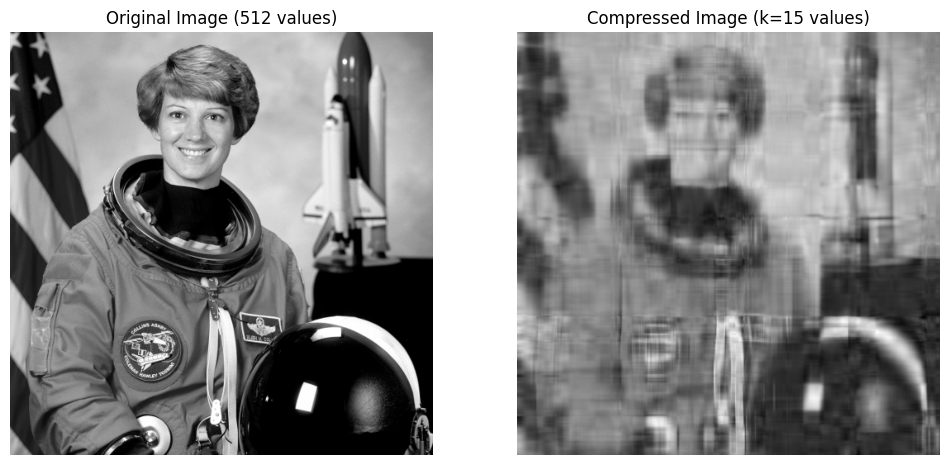

In [ ]:
# Choose how many singular values to keep (Try changing this number later!)
k = 15
compressed_img = compress_image(k, U, S, Vh)

# --- Drawing the results side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Draw Original
axes[0].imshow(img_tensor.numpy(), cmap='gray')
axes[0].set_title("Original Image (512 values)")
axes[0].axis('off')

# Draw Compressed
axes[1].imshow(compressed_img.numpy(), cmap='gray')
axes[1].set_title(f"Compressed Image (k={k} values)")
axes[1].axis('off')

plt.show()

In [ ]:
# Save the learned weights to a file named 'my_ai_brain.pth'
torch.save(model.state_dict(), 'my_ai_brain.pth')

NameError: name 'model' is not defined